<a href="https://colab.research.google.com/github/1BM23CS308/1BM23CS308_ML/blob/main/lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Accuracy: 0.9666666666666667
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         9
  versicolor       0.88      1.00      0.93         7
   virginica       1.00      0.93      0.96        14

    accuracy                           0.97        30
   macro avg       0.96      0.98      0.97        30
weighted avg       0.97      0.97      0.97        30



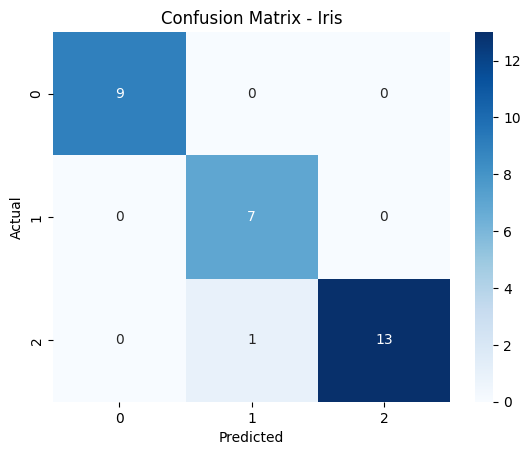

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

data = pd.read_csv("iris.csv")

X = data.drop("species", axis=1)
y = data["species"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)

y_pred = knn.predict(X_test)

print("Accuracy:",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot=True,cmap="Blues")
plt.title("Confusion Matrix - Iris")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Accuracy: 0.7272727272727273


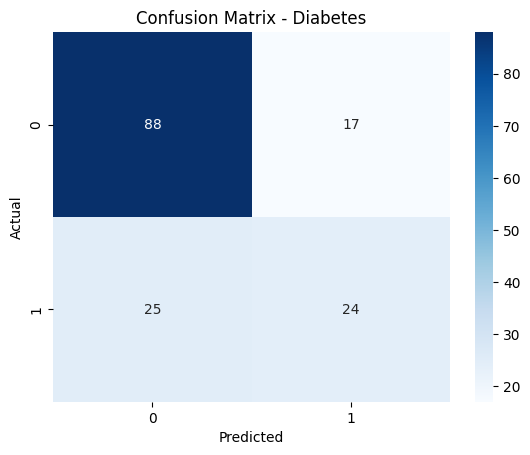

In [10]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

data = pd.read_csv("diabetes.csv")

X = data.drop("Outcome",axis=1)
y = data["Outcome"]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)

y_pred = knn.predict(X_test)

print("Accuracy:",accuracy_score(y_test,y_pred))

cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot=True,cmap="Blues")
plt.title("Confusion Matrix - Diabetes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Best K: 5
Accuracy: 0.7540983606557377
              precision    recall  f1-score   support

           0       0.74      0.71      0.73        28
           1       0.76      0.79      0.78        33

    accuracy                           0.75        61
   macro avg       0.75      0.75      0.75        61
weighted avg       0.75      0.75      0.75        61



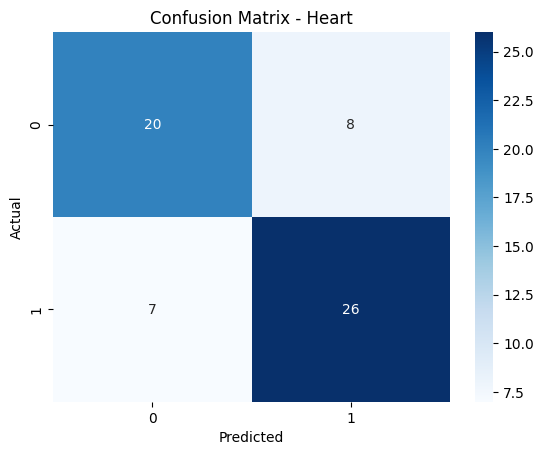

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

data = pd.read_csv("heart.csv")

X = data.drop("target",axis=1)
y = data["target"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

best_k=1
best_score=0

for k in range(1,21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train,y_train)
    score = knn.score(X_test,y_test)

    if score > best_score:
        best_score = score
        best_k = k

print("Best K:",best_k)

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train,y_train)

y_pred = knn.predict(X_test)

print("Accuracy:",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot=True,cmap="Blues")
plt.title("Confusion Matrix - Heart")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
